<a href="https://colab.research.google.com/github/ChiaraTagiullo/Machine_Learning_for_NLP/blob/main/02_vectorization_and_statistical_nlp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02 — Vectorization & Statistical NLP

In this notebook, we move from exploratory analysis to formal NLP representations.

The objectives are:

1. Represent the corpus using Bag-of-Words and TF-IDF.
2. Analyse the most important terms in the corpus.
3. Measure document similarity.
4. Explore the geometry of the corpus using dimensionality reduction.
5. Prepare the data for topic modeling and classification.

This step is essential to transform raw text into numerical features usable by machine learning models.

In [1]:
from google.colab import files
uploaded = files.upload()

Saving archelec_processed.xlsx to archelec_processed.xlsx


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 150)

In [6]:
file_name = list(uploaded.keys())[0]

df = pd.read_excel(file_name)

print("Shape:", df.shape)
df.head()

Shape: (33031, 35)


,id,date,year,month,contexte-election,contexte-tour,departement,departement-nom,departement-insee,identifiant de circonscription,titulaire-sexe,titulaire-age,titulaire-age-calcule,titulaire-age-tranche,titulaire-profession,titulaire-mandat-en-cours,titulaire-mandat-passe,titulaire-associations,titulaire-autres-statuts,titulaire-soutien,titulaire-liste,suppleant-sexe,suppleant-profession,suppleant-mandat-en-cours,suppleant-mandat-passe,suppleant-associations,suppleant-autres-statuts,suppleant-soutien,suppleant-liste,text_raw,text_clean,tokens,n_chars,n_words_raw,n_words_clean
0,EL009_L_1958_11_001_01_1_PF_01,1958-11-23,1958,11,législatives,1,10.0,Ain,01 - Ain,10.0,homme,non mentionné,non mentionné,non mentionné,industriel biscuitier,maire;conseiller général,non mentionné,non mentionné,non mentionné,Parti radical,non mentionné,homme,cultivateur,maire;conseiller général,non mentionné,non mentionné,non mentionné,Parti radical,non mentionné,"France;Élections législatives;Assemblée Nationale;Ve République ; Élections législatives de 1958, Ain - 01, circonscription n°01 : profession de f...",ain profession foi emile bouvard industriel biscuitier maire conseiller general parti radical cultivateur maire conseiller general parti radical,"['ain', 'profession', 'foi', 'emile', 'bouvard', 'industriel', 'biscuitier', 'maire', 'conseiller', 'general', 'parti', 'radical', 'cultivateur', ...",299,41,18
1,EL009_L_1958_11_001_01_1_PF_02,1958-11-23,1958,11,législatives,1,10.0,Ain,01 - Ain,10.0,homme,non mentionné,non mentionné,non mentionné,exploitant forestier,non mentionné,non mentionné,groupes de pression,non mentionné,Union pour la nouvelle République,non mentionné,homme,cultivateur,conseiller municipal,non mentionné,non mentionné,prisonnier de guerre,Union pour la nouvelle République,non mentionné,"France;Ve République;Élections législatives;Assemblée Nationale ; Élections législatives de 1958, Ain - 01, circonscription n°01 : profession de f...",ain profession foi albert jouvent exploitant forestier groupes pression union nouvelle cultivateur conseiller municipal prisonnier guerre union no...,"['ain', 'profession', 'foi', 'albert', 'jouvent', 'exploitant', 'forestier', 'groupes', 'pression', 'union', 'nouvelle', 'cultivateur', 'conseille...",353,52,18
2,EL009_L_1958_11_001_01_1_PF_03,1958-11-23,1958,11,législatives,1,10.0,Ain,01 - Ain,10.0,homme,non mentionné,non mentionné,non mentionné,ouvrier,non mentionné,non mentionné,politique,résistant,Parti communiste français,non mentionné,homme,cultivateur,non mentionné,non mentionné,non mentionné,non mentionné,Parti communiste français,non mentionné,"Élections législatives;France;Assemblée Nationale;Ve République ; Élections législatives de 1958, Ain - 01, circonscription n°01 : profession de f...",ain profession foi emile machurat ouvrier politique resistant parti communiste francais cultivateur parti communiste francais,"['ain', 'profession', 'foi', 'emile', 'machurat', 'ouvrier', 'politique', 'resistant', 'parti', 'communiste', 'francais', 'cultivateur', 'parti', ...",280,40,15
3,EL009_L_1958_11_001_01_1_PF_04,1958-11-23,1958,11,législatives,1,10.0,Ain,01 - Ain,10.0,homme,1890,68,entre 60 et 69 ans,non mentionné,maire,non mentionné,professionnel,non mentionné,non mentionné,non mentionné,homme,greffier de paix,conseiller municipal;conseiller général,non mentionné,non mentionné,combattant,non mentionné,non mentionné,"Élections législatives;France;Assemblée Nationale;Ve République ; Élections législatives de 1958, Ain - 01, circonscription n°01 : profession de f...",ain profession foi amedee mercier maire professionnel greffier paix conseiller municipal conseiller general combattant,"['ain', 'profession', 'foi', 'amedee', 'mercier', 'maire', 'professionnel', 'greffier', 'paix', 'conseiller', 'municipal', 'conseiller', 'general'...",274,38,14
4,EL009_L_1958_11_001_01_1_PF_05,1958-11-23,1958,11,législatives,1,10.0,Ain,01 - Ain,10.0,homme,36,36,entre 30 et 39 ans,docteur-vétérinaire,maire;conseiller 

## 1. Dataset check

We first verify that the processed dataset has been loaded correctly and that the textual variables created in the previous notebook are available.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33031 entries, 0 to 33030
Data columns (total 35 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              33031 non-null  object        
 1   date                            33031 non-null  datetime64[ns]
 2   year                            33031 non-null  int64         
 3   month                           33031 non-null  int64         
 4   contexte-election               33031 non-null  object        
 5   contexte-tour                   33031 non-null  int64         
 6   departement                     32535 non-null  float64       
 7   departement-nom                 32670 non-null  object        
 8   departement-insee               32667 non-null  object        
 9   identifiant de circonscription  31923 non-null  float64       
 10  titulaire-sexe                  33031 non-null  object        
 11  ti

In [8]:
required_columns = ["text_raw", "text_clean", "tokens", "n_words_clean"]

for col in required_columns:
    print(col, "->", col in df.columns)

text_raw -> True
text_clean -> True
tokens -> True
n_words_clean -> True


In [9]:
df[["id", "date", "year", "text_clean", "n_words_clean"]].head()

,id,date,year,text_clean,n_words_clean
0,EL009_L_1958_11_001_01_1_PF_01,1958-11-23,1958,ain profession foi emile bouvard industriel biscuitier maire conseiller general parti radical cultivateur maire conseiller general parti radical,18
1,EL009_L_1958_11_001_01_1_PF_02,1958-11-23,1958,ain profession foi albert jouvent exploitant forestier groupes pression union nouvelle cultivateur conseiller municipal prisonnier guerre union no...,18
2,EL009_L_1958_11_001_01_1_PF_03,1958-11-23,1958,ain profession foi emile machurat ouvrier politique resistant parti communiste francais cultivateur parti communiste francais,15
3,EL009_L_1958_11_001_01_1_PF_04,1958-11-23,1958,ain profession foi amedee mercier maire professionnel greffier paix conseiller municipal conseiller general combattant,14
4,EL009_L_1958_11_001_01_1_PF_05,1958-11-23,1958,ain profession foi hubert pernin docteur veterinaire maire conseiller general centre national independants paysans cultivateur president cooperati...,22


## 2. Preparing the textual input

We use the cleaned textual representation produced in the first notebook.

Documents with missing or extremely short cleaned text are removed because they do not contain enough lexical information for statistical NLP representations.

In [10]:
df = df[df["text_clean"].notna()].copy()
df = df[df["text_clean"].str.strip() != ""].copy()
df = df[df["n_words_clean"] > 3].copy()

df = df.reset_index(drop=True)

print("Remaining documents:", len(df))

Remaining documents: 33029


In [11]:
df["n_words_clean"].describe()

,n_words_clean
count,33029.000000
mean,19.450846
std,7.632051
min,4.000000
25%,14.000000
50%,19.000000
75%,23.000000
max,89.000000


## 3. Bag-of-Words representation

The Bag-of-Words model represents each document as a vector of word counts.

This is one of the simplest and most classical text representations in NLP: it ignores word order but captures the frequency of lexical units across documents.

In [12]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer_bow = CountVectorizer(
    max_df=0.95,
    min_df=5,
    max_features=5000
)

X_bow = vectorizer_bow.fit_transform(df["text_clean"])

print("BoW matrix shape:", X_bow.shape)

BoW matrix shape: (33029, 3640)


In [13]:
bow_terms = np.array(vectorizer_bow.get_feature_names_out())
bow_frequencies = np.asarray(X_bow.sum(axis=0)).ravel()

bow_df = pd.DataFrame({
    "term": bow_terms,
    "frequency": bow_frequencies
}).sort_values("frequency", ascending=False)

bow_df.head(30)

,term,frequency
2651,parti,24968
3466,union,23266
877,conseiller,20373
2233,maire,17266
3253,socialiste,15290
1456,francais,11801
855,communiste,11594
1540,general,10782
1525,gauche,10400
2972,rassemblement,9741


<Figure size 1000x700 with 0 Axes>

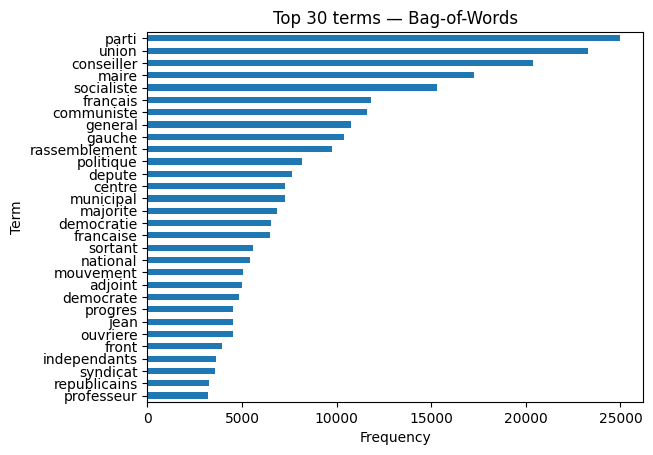

In [14]:
plt.figure(figsize=(10, 7))
bow_df.head(30).sort_values("frequency").plot(
    x="term",
    y="frequency",
    kind="barh",
    legend=False
)
plt.title("Top 30 terms — Bag-of-Words")
plt.xlabel("Frequency")
plt.ylabel("Term")
plt.show()

### Interpretation — Bag-of-Words

The Bag-of-Words representation confirms that the corpus is dominated by political and institutional vocabulary.

The most frequent terms include party labels such as "parti", "socialiste", and "communiste", as well as institutional roles such as "conseiller", "maire", "député", and "municipal". This indicates that the textual representation is mainly structured around political affiliation, elected offices, and candidate profiles.

The presence of terms such as "union", "rassemblement", "gauche", and "centre" also suggests that political positioning is a central dimension of the corpus.

Overall, Bag-of-Words captures the main lexical field of the dataset, but it mostly reflects globally frequent terms rather than terms that distinguish documents from one another.

## 4. TF-IDF representation

TF-IDF gives more weight to terms that are frequent in a document but not too frequent across the whole corpus.

Compared to raw frequency, TF-IDF is usually more informative for document comparison, clustering, and classification.

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer_tfidf = TfidfVectorizer(
    max_df=0.95,
    min_df=5,
    max_features=5000
)

X_tfidf = vectorizer_tfidf.fit_transform(df["text_clean"])

print("TF-IDF matrix shape:", X_tfidf.shape)

TF-IDF matrix shape: (33029, 3640)


In [16]:
tfidf_terms = np.array(vectorizer_tfidf.get_feature_names_out())
tfidf_scores = np.asarray(X_tfidf.mean(axis=0)).ravel()

tfidf_df = pd.DataFrame({
    "term": tfidf_terms,
    "mean_tfidf": tfidf_scores
}).sort_values("mean_tfidf", ascending=False)

tfidf_df.head(30)

,term,mean_tfidf
2651,parti,0.071420
3466,union,0.069422
877,conseiller,0.056223
3253,socialiste,0.052092
2233,maire,0.051721
1456,francais,0.048401
855,communiste,0.047224
2972,rassemblement,0.041751
1525,gauche,0.040267
1540,general,0.037914


<Figure size 1000x700 with 0 Axes>

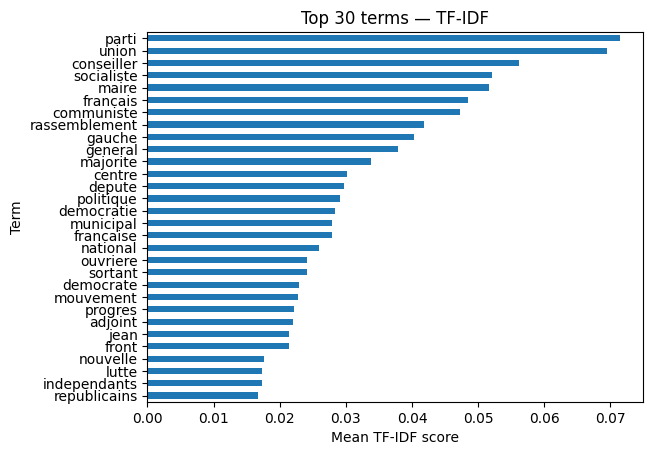

In [17]:
plt.figure(figsize=(10, 7))
tfidf_df.head(30).sort_values("mean_tfidf").plot(
    x="term",
    y="mean_tfidf",
    kind="barh",
    legend=False
)
plt.title("Top 30 terms — TF-IDF")
plt.xlabel("Mean TF-IDF score")
plt.ylabel("Term")
plt.show()

### Interpretation — TF-IDF

The TF-IDF ranking is close to the Bag-of-Words ranking, which indicates that the most frequent words are also highly informative in this corpus.

Terms such as "parti", "union", "conseiller", "socialiste", "maire", "communiste", and "rassemblement" remain central. This suggests that political affiliation and institutional roles are not only frequent, but also discriminative across documents.

Compared to raw frequency, TF-IDF gives slightly more importance to terms such as "majorité", "ouvrière", "lutte", and "indépendants", which are useful for distinguishing specific political families or ideological profiles.

This confirms that TF-IDF is an appropriate representation for similarity analysis and clustering.

## 5. Comparing Bag-of-Words and TF-IDF

We compare the most frequent words according to Bag-of-Words with the most important terms according to TF-IDF.

This helps distinguish between globally frequent vocabulary and lexically discriminative vocabulary.

In [18]:
comparison_df = pd.DataFrame({
    "top_bow_terms": bow_df.head(30)["term"].values,
    "bow_frequency": bow_df.head(30)["frequency"].values,
    "top_tfidf_terms": tfidf_df.head(30)["term"].values,
    "mean_tfidf": tfidf_df.head(30)["mean_tfidf"].values
})

comparison_df

,top_bow_terms,bow_frequency,top_tfidf_terms,mean_tfidf
0,parti,24968,parti,0.071420
1,union,23266,union,0.069422
2,conseiller,20373,conseiller,0.056223
3,maire,17266,socialiste,0.052092
4,socialiste,15290,maire,0.051721
5,francais,11801,francais,0.048401
6,communiste,11594,communiste,0.047224
7,general,10782,rassemblement,0.041751
8,gauche,10400,gauche,0.040267
9,rassemblement,9741,general,0.037914


### Interpretation — BoW vs TF-IDF comparison

The comparison between Bag-of-Words and TF-IDF shows a strong overlap between the two rankings.

This means that the corpus contains a relatively stable and repetitive political vocabulary. The most frequent words are also among the most informative terms because they refer to key political identities, parties, and institutions.

However, TF-IDF slightly changes the ranking by promoting more specific ideological or organizational terms. For instance, words related to particular political traditions or movements become more visible.

This difference is important because machine learning models based on TF-IDF are likely to rely less on generic frequency and more on terms that help separate documents lexically.

## 6. Document similarity

Using the TF-IDF matrix, we compute cosine similarity between selected documents.

Cosine similarity measures how close two documents are in the vector space. A high score means that two documents share similar lexical content.

In [19]:
from sklearn.metrics.pairwise import cosine_similarity

def show_similar_documents(doc_index, top_n=5):
    selected_vector = X_tfidf[doc_index]
    similarities = cosine_similarity(selected_vector, X_tfidf).ravel()

    most_similar_indices = similarities.argsort()[::-1][1:top_n+1]

    print("Original document index:", doc_index)
    print("Original text:")
    print(df.iloc[doc_index]["text_clean"])
    print("\n" + "="*80 + "\n")

    results = []

    for idx in most_similar_indices:
        results.append({
            "document_index": idx,
            "similarity": similarities[idx],
            "year": df.iloc[idx]["year"],
            "election": df.iloc[idx]["contexte-election"],
            "support": df.iloc[idx]["titulaire-soutien"],
            "profession": df.iloc[idx]["titulaire-profession"],
            "text_clean": df.iloc[idx]["text_clean"]
        })

    return pd.DataFrame(results)

similar_docs = show_similar_documents(doc_index=0, top_n=5)
similar_docs

Original document index: 0
Original text:
ain profession foi emile bouvard industriel biscuitier maire conseiller general parti radical cultivateur maire conseiller general parti radical




,document_index,similarity,year,election,support,profession,text_clean
0,4400,0.534725,1962,législatives,Parti radical et radical-socialiste,notaire,vaucluse profession foi andre bruey notaire maire conseiller general parti radical radical socialiste maire conseiller general parti radical radic...
1,1528,0.527040,1958,législatives,Parti républicain radical et radical-socialiste,chirurgien-dentiste,saone loire profession foi emile moudens chirurgien dentiste maire conseiller general parti republicain radical radical socialiste docteur maire p...
2,691,0.512124,1958,législatives,Parti radical et radical-socialiste,non mentionné,indre loire profession foi joseph renard maire conseiller general resistant deporte parti radical radical socialiste cultivateur maire parti radic...
3,5010,0.502733,1962,législatives,Parti républicain radical et radical-socialiste;indépendants de gauche,non mentionné,yonne profession foi jean michel renaitour conseiller municipal conseiller general maire depute parti republicain radical radical socialiste indep...
4,4454,0.500634,1962,législatives,Parti républicain radical et radical-socialiste;indépendants de gauche,non mentionné,yonne profession foi jean michel renaitour conseiller municipal conseiller general maire depute parti republicain radical radical socialiste indep...


### Interpretation — Document similarity

The similarity analysis shows that the closest documents to the selected example share a very coherent political and institutional profile.

The most similar documents are all legislative election records from 1958 or 1962, and several are associated with the Radical or Radical-Socialist political family. They also share recurring descriptors such as "maire", "conseiller général", and references to local political offices.

This confirms that cosine similarity based on TF-IDF captures meaningful lexical proximity. In this corpus, similarity mainly reflects shared political affiliation, institutional roles, and candidate background.

At the same time, this result also confirms that the textual representation is strongly metadata-driven: similar documents are close because they share structured descriptors rather than because they express similar argumentative content.

## 7. Dimensionality reduction with Truncated SVD

The TF-IDF matrix is high-dimensional and sparse. Instead of classical PCA, we use Truncated SVD, which is better suited for sparse text matrices.

This method allows us to project documents into a two-dimensional space for visualization.

In [20]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=2, random_state=42)
X_svd = svd.fit_transform(X_tfidf)

print("Explained variance ratio:", svd.explained_variance_ratio_)
print("Total explained variance:", svd.explained_variance_ratio_.sum())

Explained variance ratio: [0.01882039 0.03520315]
Total explained variance: 0.05402353777250174


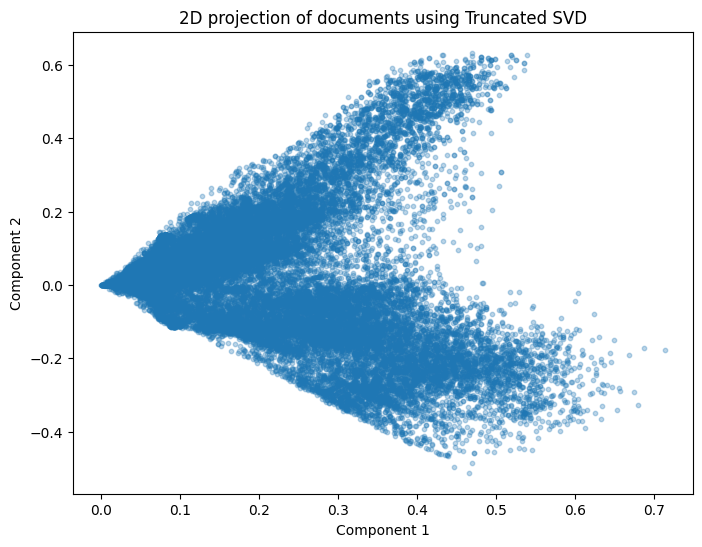

In [21]:
plt.figure(figsize=(8, 6))
plt.scatter(X_svd[:, 0], X_svd[:, 1], alpha=0.3, s=10)
plt.title("2D projection of documents using Truncated SVD")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()

### Interpretation — SVD projection

The two-dimensional SVD projection reveals a continuous triangular structure rather than clearly separated groups.

Most documents are concentrated near the origin, while several branches extend outward. This suggests that many documents share a common core vocabulary, while some subsets are differentiated by more specific political or institutional terms.

The absence of sharply isolated clusters indicates that the corpus is lexically continuous. This is expected given that many documents follow a similar structure and contain recurring expressions related to elections, professions, parties, and local offices.

The SVD projection is therefore useful for visual exploration, but it should not be interpreted as evidence of naturally well-separated categories.

## 8. Visualization by political support

We now color the two-dimensional projection according to the most frequent political supports.

This helps evaluate whether political affiliation corresponds to visible lexical structure.

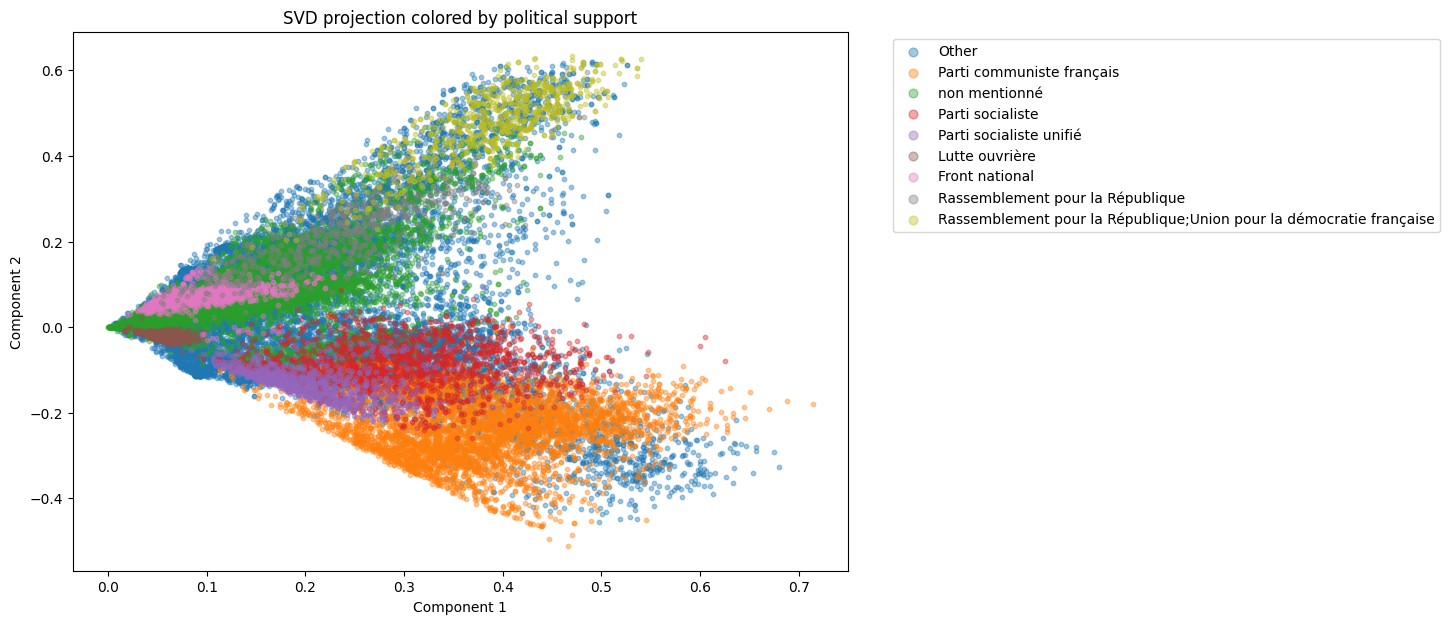

In [22]:
top_supports = df["titulaire-soutien"].value_counts().head(8).index

df["support_grouped"] = df["titulaire-soutien"].apply(
    lambda x: x if x in top_supports else "Other"
)

plt.figure(figsize=(10, 7))

for support in df["support_grouped"].unique():
    mask = df["support_grouped"] == support
    plt.scatter(
        X_svd[mask, 0],
        X_svd[mask, 1],
        alpha=0.4,
        s=10,
        label=support
    )

plt.title("SVD projection colored by political support")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.legend(markerscale=2, bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

### Interpretation — Political support in SVD space

Coloring the SVD projection by political support reveals a meaningful relationship between lexical structure and political affiliation.

Some political families occupy partially distinct regions of the vector space. For example, documents associated with the Communist Party and Socialist Party tend to form visible areas, suggesting that their lexical profiles are relatively coherent.

However, there is still substantial overlap between groups. This overlap reflects the fact that many political documents share institutional vocabulary, regardless of party affiliation.

Overall, political support appears to be an important source of lexical variation, but not the only one. Candidate roles, professions, local mandates, and historical period also contribute to the structure of the vector space.

## 9. K-Means clustering

We apply K-Means clustering to the TF-IDF representation.

The goal is not to produce final labels, but to explore whether the corpus contains latent groups of lexically similar documents.

In [23]:
from sklearn.cluster import KMeans

k = 5

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

df["cluster"] = kmeans.fit_predict(X_tfidf)

df["cluster"].value_counts().sort_index()

,count
cluster,
0,2822
1,16825
2,6300
3,2248
4,4834


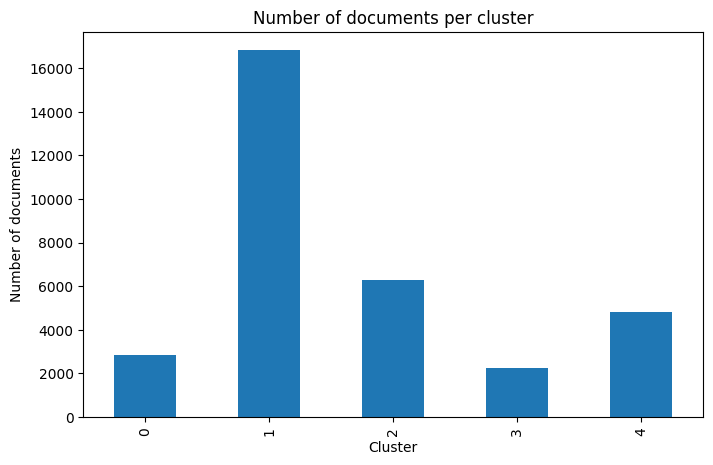

In [24]:
plt.figure(figsize=(8, 5))
df["cluster"].value_counts().sort_index().plot(kind="bar")
plt.title("Number of documents per cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of documents")
plt.show()

### Interpretation — Cluster distribution

The K-Means clustering produces highly imbalanced clusters.

Cluster 1 is by far the largest group, while clusters 0 and 3 contain substantially fewer documents. This imbalance suggests that a large part of the corpus shares a broad common vocabulary, while smaller subsets are characterized by more specific lexical patterns.

The result is coherent with the previous SVD projection: the corpus does not split into equally sized groups, but rather contains a dominant central mass and several more specialized regions.

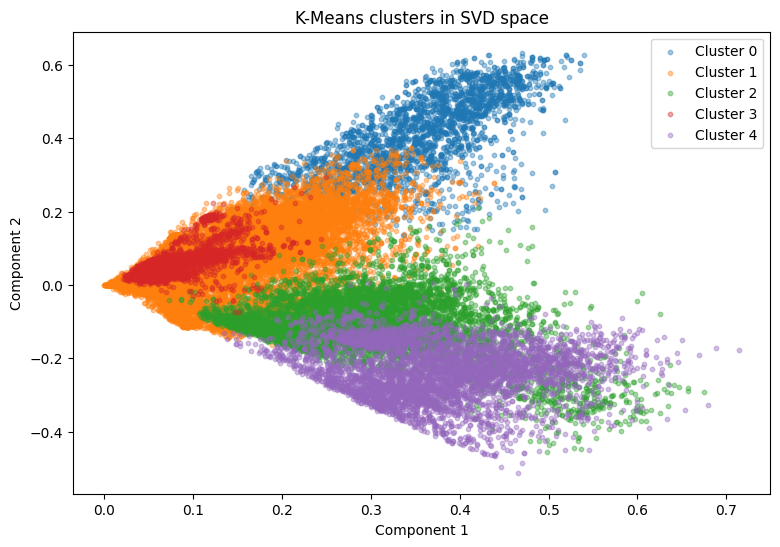

In [25]:
plt.figure(figsize=(9, 6))

for cluster_id in sorted(df["cluster"].unique()):
    mask = df["cluster"] == cluster_id
    plt.scatter(
        X_svd[mask, 0],
        X_svd[mask, 1],
        alpha=0.4,
        s=10,
        label=f"Cluster {cluster_id}"
    )

plt.title("K-Means clusters in SVD space")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.legend()
plt.show()

### Interpretation — K-Means clusters in SVD space

The visualization of K-Means clusters in the SVD space shows partial but not complete separation.

Clusters occupy different regions of the projection, especially along the upper and lower branches of the triangular structure. This indicates that K-Means captures real lexical differences in the corpus.

However, the clusters overlap near the origin, where many documents share common political and institutional vocabulary. This confirms that clustering should be interpreted as an exploratory tool rather than as a definitive classification of the corpus.

## 10. Interpreting clusters through top terms

To understand what each cluster represents, we inspect the most characteristic terms associated with each cluster centroid.

In [26]:
terms = np.array(vectorizer_tfidf.get_feature_names_out())
centroids = kmeans.cluster_centers_

top_terms_per_cluster = {}

for cluster_id in range(k):
    top_indices = centroids[cluster_id].argsort()[::-1][:15]
    top_terms = terms[top_indices]
    top_terms_per_cluster[cluster_id] = top_terms

for cluster_id, terms_cluster in top_terms_per_cluster.items():
    print(f"Cluster {cluster_id}:")
    print(", ".join(terms_cluster))
    print()

Cluster 0:
union, rassemblement, democratie, francaise, centre, conseiller, majorite, maire, general, nouvelle, depute, independants, sortant, national, regional

Cluster 1:
union, maire, conseiller, general, majorite, progres, lutte, depute, centre, ouvriere, mouvement, republicains, sortant, presidentielle, defense

Cluster 2:
socialiste, parti, gauche, democrate, unifie, federation, maire, conseiller, section, internationale, radicaux, general, ouvriere, francaise, politique

Cluster 3:
front, national, entente, liste, populaire, verts, generation, ecologie, ecologistes, conseiller, politique, regional, municipal, retraite, jean

Cluster 4:
communiste, francais, parti, gauche, forces, conseiller, union, politique, maire, municipal, changement, rassemblement, ouvrier, adjoint, programme



### Interpretation — Cluster profiles

The top terms associated with each cluster make the clustering results interpretable.

Cluster 0 appears to correspond to a center-right or institutional political profile, with terms such as "union", "rassemblement", "démocratie", "centre", "majorité", and "indépendants".

Cluster 1 is more general and institutional, with terms such as "maire", "conseiller", "général", "député", and "majorité". Its large size suggests that it captures a broad mainstream political profile centered on local and parliamentary offices.

Cluster 2 is clearly associated with the socialist and left-wing tradition, with terms such as "socialiste", "gauche", "démocrate", "unifié", "fédération", and "internationale".

Cluster 3 appears to group more recent or alternative political profiles, including terms such as "front national", "verts", "écologie", "écologistes", and "génération".

Cluster 4 is strongly associated with the Communist Party and left-wing political vocabulary, with terms such as "communiste", "français", "parti", "gauche", "forces", "ouvrier", and "programme".

Overall, the clusters are not arbitrary: they reflect meaningful political families and institutional profiles. This confirms that TF-IDF combined with K-Means can uncover interpretable lexical structures in the corpus.

In [27]:
cluster_summary = []

for cluster_id in range(k):
    subset = df[df["cluster"] == cluster_id]

    cluster_summary.append({
        "cluster": cluster_id,
        "n_documents": len(subset),
        "most_common_support": subset["titulaire-soutien"].value_counts(dropna=False).index[0],
        "most_common_profession": subset["titulaire-profession"].value_counts(dropna=False).index[0],
        "most_common_election": subset["contexte-election"].value_counts(dropna=False).index[0],
        "median_year": subset["year"].median()
    })

cluster_summary_df = pd.DataFrame(cluster_summary)
cluster_summary_df

,cluster,n_documents,most_common_support,most_common_profession,most_common_election,median_year
0,0,2822,Rassemblement pour la République;Union pour la démocratie française,non mentionné,législatives,1988.0
1,1,16825,non mentionné,non mentionné,législatives,1978.0
2,2,6300,Parti socialiste,non mentionné,législatives,1973.0
3,3,2248,Front national,non mentionné,législatives,1993.0
4,4,4834,Parti communiste français,non mentionné,législatives,1973.0


## 11. Saving the vectorized dataset

We save the dataset with cluster labels for later use in topic modeling and classification.

In [28]:
df.to_excel("archelec_vectorized_with_clusters.xlsx", index=False)
df.to_csv("archelec_vectorized_with_clusters.csv", index=False)

files.download("archelec_vectorized_with_clusters.xlsx")
files.download("archelec_vectorized_with_clusters.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Conclusions

This notebook introduced classical vector-space methods for the analysis of the Archelec corpus.

The Bag-of-Words representation showed that the corpus is dominated by political, institutional, and socio-professional vocabulary. The most frequent terms refer to parties, political families, elected offices, and candidate profiles.

TF-IDF confirmed that these same terms are not only frequent but also discriminative. Political labels such as "socialiste", "communiste", "front", "centre", and "indépendants" help distinguish documents and structure the vector space.

The document similarity analysis showed that TF-IDF captures meaningful proximity between documents. Similar documents tend to share political affiliation, historical period, local mandates, and candidate characteristics.

The SVD projection revealed that the corpus has a continuous structure rather than sharply separated categories. Nevertheless, coloring the projection by political support showed that party affiliation is an important source of lexical variation.

Finally, K-Means clustering identified interpretable groups corresponding to broad political families: socialist, communist, center-right/institutional, and alternative or far-right/ecologist profiles. The clusters are imbalanced and partially overlapping, but their top terms are coherent and meaningful.

Overall, the results show that the Archelec corpus is suitable for statistical NLP methods. At the same time, the analysis confirms that the textual data is short, structured, and strongly metadata-driven. For this reason, future analyses should interpret topics and clusters as political identity profiles rather than as full argumentative themes.

The next notebook will focus on topic modeling in order to identify latent thematic structures in the corpus.